# Introduction
Made by : Michael Man, Minh Ho-Hoang

We aim to use data from the stock market to see if there are trends and prediction that can be made from short term data.

We hypothesize that there are some trends which can be observed, but we are not sure how reliable it will be, as there are many variables in real life that affects the stock market.

# Apache Spark / PySpark

[Spark 3.3.x](https://spark.apache.org/docs/3.3.0/)  

Reference/API Links


*   [Apache Spark Quick Start](https://spark.apache.org/docs/3.3.0/quick-start.html)
*   [PySpark v3.3.0 API](https://spark.apache.org/docs/3.3.0/api/python/reference/index.html)
*    [RDD Programming Guide](https://spark.apache.org/docs/3.3.0/rdd-programming-guide.html)
*    [Spark SQL Programming Guide](https://spark.apache.org/docs/3.3.0/sql-programming-guide.html)









In [ ]:
!apt-get update -y
!apt-get install -y openjdk-8-jdk-headless


!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,598 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy In

In [ ]:
#Copy and Pasted Code from A Migler
!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

openjdk-8-jdk-headless is already the newest version (8u472-ga-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 62 not upgraded.


In [ ]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession

# import PySpark aggregate functions with underscores to avoid collision with Python sum, etc
from pyspark.sql.functions import sum as _sum, avg as _avg, count as _count, max as _max

# useful SQL functions for the queries below
from pyspark.sql.functions import col, lit, round, month, to_date, to_timestamp, hour, when, expr, desc

from pyspark.sql.window import Window
from pyspark.sql.functions import rank, dense_rank, row_number, lag, lead

sc = SparkContext.getOrCreate()
spark = SparkSession(sc)

# Dataset
Our data is taken from [www.kaggle.com](https://www.kaggle.com/datasets/codebynadiia/s-and-p-500-stocks-dataset-first-half-2025)

The data is about the S&P 500 stocks. It has an opening and closing price as well as trading volume.

We are able to use the kagglehub import to download the csv files, and transfer it into a usable dataset.

In [ ]:
import glob
import kagglehub
import os

local_dir = kagglehub.dataset_download("codebynadiia/s-and-p-500-stocks-dataset-first-half-2025")

csv_path = os.path.join(local_dir, "sp500_2025_h1_wide_clean.csv")

df = spark.read.option("header", True).option("inferSchema", True).csv(csv_path)

df.show(5, truncate=False)

Using Colab cache for faster access to the 's-and-p-500-stocks-dataset-first-half-2025' dataset.
+--------------+------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+--

In [ ]:
from pyspark.sql import functions as F

cols = [c for c in df.columns if "_" in c and ("opening" in c or "closing" in c or "volume" in c)]

long_df = (
    df.selectExpr("company_name", "ticker", *[f"stack({len(cols)//3}, " + ", "
    .join([f"'{c.split('_')[0]}', `{c}`" for c in cols if c.endswith('opening')]) + ") as (date, opening)"])
)

opening_cols = [c for c in df.columns if c.endswith('_opening')]
closing_cols = [c for c in df.columns if c.endswith('_closing')]
volume_cols  = [c for c in df.columns if c.endswith('_volume')]

dates = [c.split('_')[0] for c in opening_cols]

from functools import reduce

dfs = []
for d in dates:
    temp = (
        df.select(
            "company_name", "ticker",
            F.lit(d).alias("date"),
            F.col(f"{d}_opening").alias("opening"),
            F.col(f"{d}_closing").alias("closing"),
            F.col(f"{d}_volume").alias("volume")
        )
    )
    dfs.append(temp)

long_df = reduce(lambda a, b: a.unionByName(b), dfs)


In [ ]:
long_df.show(10)

+--------------------+------+----------+-------+-------+---------+
|        company_name|ticker|      date|opening|closing|   volume|
+--------------------+------+----------+-------+-------+---------+
|              Nvidia|  NVDA|02-01-2025|  136.0| 138.31|198247166|
|           Microsoft|  MSFT|02-01-2025| 425.53| 418.58| 16896469|
|          Apple Inc.|  AAPL|02-01-2025|248.657|243.582| 55802016|
|              Amazon|  AMZN|02-01-2025| 222.03| 220.22| 33956579|
|      Meta Platforms|  META|02-01-2025| 589.72| 599.24| 12682269|
|            Broadcom|  AVGO|02-01-2025|236.155| 231.98| 31525830|
|Alphabet Inc. (Cl...| GOOGL|02-01-2025| 190.65| 189.43| 20370828|
|Alphabet Inc. (Cl...|  GOOG|02-01-2025|191.485| 190.63| 17545162|
|         Tesla, Inc.|  TSLA|02-01-2025|  390.1| 379.28|109710749|
|  Berkshire Hathaway| BRK.B|02-01-2025| 455.96|  451.1|  3751194|
+--------------------+------+----------+-------+-------+---------+
only showing top 10 rows



# Question: Which stocks had the best preformance during the first half of 2025?

In [ ]:
raw = (
    long_df.select('ticker', 'date','opening', 'closing')
    .withColumn("date", to_date("date", "dd-MM-yyyy"))
    .withColumn("date_asc", row_number().over(Window.partitionBy("ticker").orderBy("date")))
    .withColumn("date_desc", row_number().over(Window.partitionBy("ticker").orderBy(desc("date"))))
    .groupBy("ticker")
    .agg(
        _max(when(col("date_asc") == 1, col("opening"))).alias("first_opening"),
        _max(when(col("date_desc") == 1, col("closing"))).alias("last_closing")
    )
    .withColumn("price_change", round(col("last_closing") - col("first_opening"), 2))
    .select("ticker", "price_change")
    .orderBy(desc("price_change"))
)

raw.show(10)


+------+------------+
|ticker|price_change|
+------+------------+
|  BKNG|      798.57|
|   AZO|      490.84|
|  NFLX|      443.63|
|  KLAC|      261.05|
|   TDG|      248.96|
|  AXON|      223.87|
|   GEV|      196.04|
|  CRWD|      162.79|
|   MCK|      160.39|
|  INTU|      150.63|
+------+------------+
only showing top 10 rows



In [ ]:
percent = (
    long_df.select('ticker', 'date','opening', 'closing')
    .withColumn("date", to_date("date", "dd-MM-yyyy"))
    .withColumn("date_asc", row_number().over(Window.partitionBy("ticker").orderBy("date")))
    .withColumn("date_desc", row_number().over(Window.partitionBy("ticker").orderBy(desc("date"))))
    .groupBy("ticker")
    .agg(
        _max(when(col("date_asc") == 1, col("opening"))).alias("first_opening"),
        _max(when(col("date_desc") == 1, col("closing"))).alias("last_closing")
    )
    .withColumn("price_change_percentage", round((col("last_closing") - col("first_opening")) / col("first_opening"), 2))
    .select("ticker", "price_change_percentage")
    .orderBy(desc("price_change_percentage"))
)

percent.show(10)

+------+-----------------------+
|ticker|price_change_percentage|
+------+-----------------------+
|  HOOD|                   1.43|
|  PLTR|                   0.79|
|   NRG|                   0.76|
|   HWM|                   0.69|
|   STX|                   0.65|
|   GEV|                   0.59|
|  SMCI|                   0.58|
|   NEM|                   0.54|
|   CVS|                   0.53|
|    GE|                   0.53|
+------+-----------------------+
only showing top 10 rows



[*********************100%***********************]  19 of 19 completed


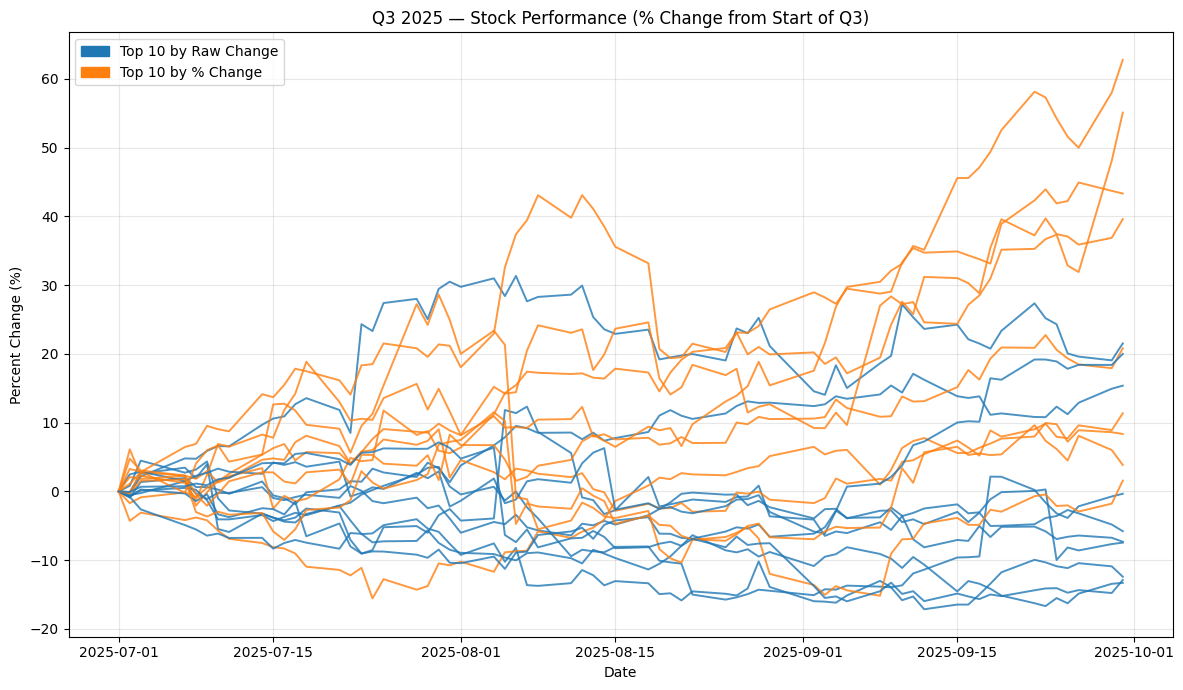

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

top_raw = ["BKNG","AZO","NFLX","KLAC","TDG","AXON","GEV","CRWD","MKC","INTU"]
top_pct = ["HOOD","PLTR","NRG","HWM","STX","GEV","SMCI","NEM","CVS","GE"]

all_tickers = sorted(set(top_raw + top_pct))
start, end = "2025-07-01", "2025-10-01"

data = yf.download(all_tickers, start=start, end=end, auto_adjust=False)["Close"]

norm = (data / data.iloc[0] - 1) * 100

#norm = norm.rolling(window=3).mean()

df = norm.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="PctChange")
df["Group"] = df["Ticker"].apply(lambda t: "Raw Top 10" if t in top_raw else "Pct Top 10")


#matplot
plt.figure(figsize=(12,7))
for ticker, group_df in df.groupby("Ticker"):
    color = "tab:blue" if ticker in top_raw else "tab:orange"
    plt.plot(group_df["Date"], group_df["PctChange"],
             label=ticker, color=color, linewidth=1.4, alpha=0.8)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title="Ticker", ncol=2, fontsize=8)

plt.title("Q3 2025 — Stock Performance (% Change from Start of Q3)")
plt.xlabel("Date")
plt.ylabel("Percent Change (%)")

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="tab:blue", label="Top 10 by Raw Change"),
    Patch(color="tab:orange", label="Top 10 by % Change")
], loc="upper left")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


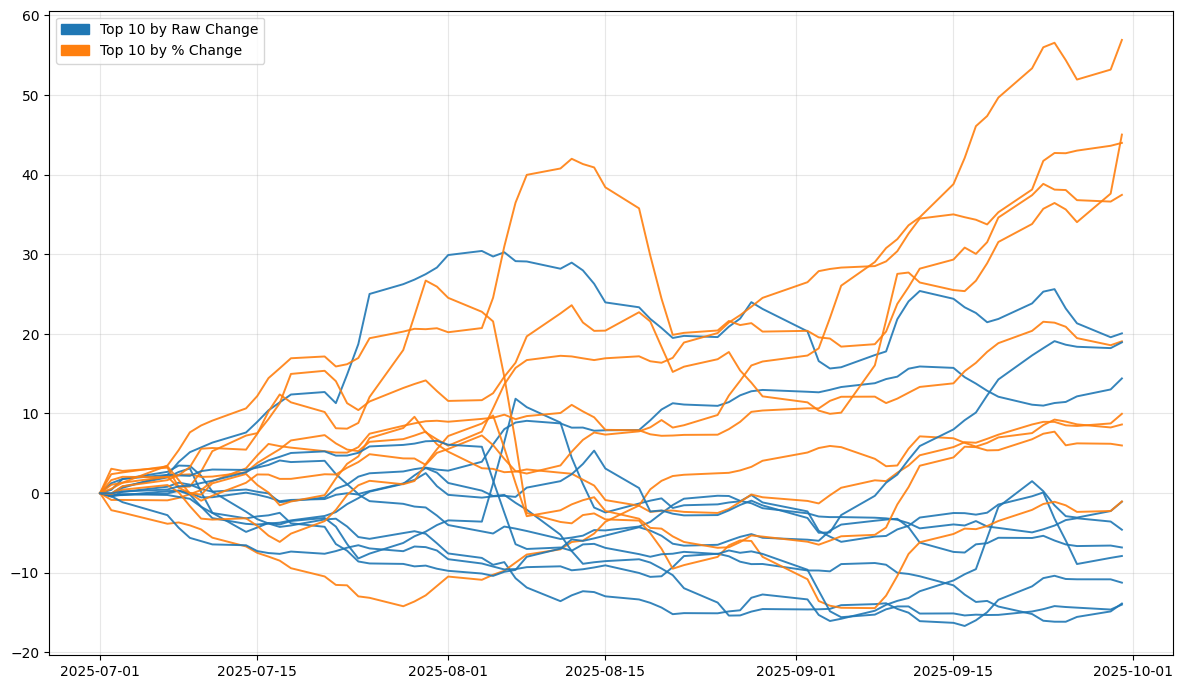

In [ ]:
spark_df = spark.createDataFrame(df)


window_average = (
    spark_df.withColumn("Date", to_date("Date", "yyyy-MM-dd"))
    .withColumn("window", _avg(col("PctChange")).over(Window.partitionBy("Ticker").orderBy("Date").rowsBetween(-2, 0))))

pd_df = window_average.toPandas()

plt.figure(figsize=(12,7))

for ticker, group_df in pd_df.groupby("Ticker"):
    color = "tab:blue" if ticker in top_raw else "tab:orange"
    plt.plot(group_df["Date"], group_df["window"],
             label=ticker, color=color, linewidth=1.4, alpha=0.9)

plt.legend(handles=[
    Patch(color="tab:blue", label="Top 10 by Raw Change"),
    Patch(color="tab:orange", label="Top 10 by % Change")
], loc="upper left")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




# Question: Which company had the singled biggest daily gain and loss, and how did they do in the long term?

In [ ]:
prices_df = (
    long_df
    .withColumn("date", F.to_date("date", "yyyy-MM-dd"))
    .filter(F.col("closing").isNotNull())
)

w = Window.partitionBy("ticker").orderBy("date")

# previous day's close, daily dollar change, and daily percentage change
prices_with_changes = (
    prices_df
    .withColumn("prev_closing", F.lag("closing").over(w))
    .withColumn("daily_change", F.col("closing") - F.col("prev_closing"))
    .withColumn(
        "daily_pct_change",
        F.when(F.col("prev_closing").isNull(), None)
         .otherwise(F.col("daily_change") / F.col("prev_closing"))
    )
)

# Biggest single day gain
biggest_gain = (
    prices_with_changes
    .filter(F.col("daily_pct_change").isNotNull())
    .orderBy(F.col("daily_pct_change").desc())
    .select(
        "company_name",
        "ticker",
        "date",
        F.round("prev_closing", 2).alias("prev_close"),
        F.round("closing", 2).alias("close"),
        F.round("daily_change", 2).alias("dollar_change"),
        F.round(F.col("daily_pct_change") * 100, 2).alias("pct_change")
    )
    .limit(1)
)

# Biggest single day loss
biggest_loss = (
    prices_with_changes
    .filter(F.col("daily_pct_change").isNotNull())
    .orderBy(F.col("daily_pct_change").asc())
    .select(
        "company_name",
        "ticker",
        "date",
        F.round("prev_closing", 2).alias("prev_close"),
        F.round("closing", 2).alias("close"),
        F.round("daily_change", 2).alias("dollar_change"),
        F.round(F.col("daily_pct_change") * 100, 2).alias("pct_change")
    )
    .limit(1)
)

print("Biggest Single Day Gain")
biggest_gain.show(truncate=False)

print("Biggest Single Day Loss")
biggest_loss.show(truncate=False)

Biggest Single Day Gain
+--------------------+------+----+----------+-----+-------------+----------+
|company_name        |ticker|date|prev_close|close|dollar_change|pct_change|
+--------------------+------+----+----------+-----+-------------+----------+
|Microchip Technology|MCHP  |NULL|35.34     |44.9 |9.56         |27.05     |
+--------------------+------+----+----------+-----+-------------+----------+

Biggest Single Day Loss
+----------------------------+------+----+----------+------+-------------+----------+
|company_name                |ticker|date|prev_close|close |dollar_change|pct_change|
+----------------------------+------+----+----------+------+-------------+----------+
|West Pharmaceutical Services|WST   |NULL|322.28    |199.11|-123.17      |-38.22    |
+----------------------------+------+----+----------+------+-------------+----------+



In [ ]:
# Price from start to end for the two companies with biggest gain and loss


ticker_gain = "MCHP"
ticker_loss = "WST"

tickers_of_interest = [ticker_gain, ticker_loss]

# filter to only those companies
df_two = (
    long_df
    .withColumn("date", F.to_date("date", "yyyy-MM-dd"))
    .filter(F.col("ticker").isin(tickers_of_interest))
    .orderBy("ticker", "date")
)

w_first = Window.partitionBy("ticker").orderBy("date").rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

# first and last closing price
df_summary = (
    df_two
    .withColumn("first_close", F.first("closing").over(w_first))
    .withColumn("last_close", F.last("closing").over(w_first))
    .withColumn("abs_change", F.col("last_close") - F.col("first_close"))
    .withColumn("pct_change", (F.col("abs_change") / F.col("first_close")) * 100)
    .select("company_name", "ticker", "first_close", "last_close",
            F.round("abs_change", 2).alias("dollar_change"),
            F.round("pct_change", 2).alias("percent_change"))
    .distinct()
)

df_summary.show(truncate=False)


+----------------------------+------+-----------+----------+-------------+--------------+
|company_name                |ticker|first_close|last_close|dollar_change|percent_change|
+----------------------------+------+-----------+----------+-------------+--------------+
|Microchip Technology        |MCHP  |56.88      |70.37     |13.49        |23.72         |
|West Pharmaceutical Services|WST   |328.39     |218.8     |-109.59      |-33.37        |
+----------------------------+------+-----------+----------+-------------+--------------+



# Problem Decomposition

To tackle the analysis, we broke everything down into small, manageable tasks instead of trying to do one giant query. First, we cleaned up the data and made sure all the important columns, especially the dates and closing prices were in the right format. Then we made a few reusable steps:

Sort by date per ticker used for daily changes

Use window functions to look at previous day prices

Create small modules like:

biggest single day gain

biggest single day loss

start to end performance

Each part used a separate DataFrame transformation so it was easy to understand and test. Once those pieces worked individually, we just combined them into a bigger story.


# Performance Tuning

Most of the performance optimization came from figuring out where Spark was doing unnecessary work.
We maded a couple of changes:

Reusing cleaned DataFrames instead of reparsing dates every time

Using .select() early to drop columns we didn’t need for certain steps

Caching the main daily change DataFrame (prices_with_changes) made all the later queries faster, since it gets reused multiple times

Making sure joins were on the smallest DataFrames possible (eg. start/end dates per ticker instead of the full table)

Overall, Spark was already fast, but avoiding repeated scans made the pipeline smoother.

# Results
Question 1:
When looking at whether raw change or percentage change is better at predicting preformance for the future, it is evident that percentage dominates. In the percentage group, there was only 1 company that had a negative returns, while the raw group had 7.

Question 2:
We have found that the biggest daily gainer actually still had a large percentage gain in the long run compared to its daily gain. The same goes for the bigges daily looser, where it still looses in the long run. This is interesting to see, as these daily gains and losses are not anomalies but actually a symptom of its long term gains or losses. It also shows that it doesn't massively rebound to its previous position.


The biggest daily looser West Pharmaceutical is a designer and manufacturer of injectable pharmaceutical packaging and delivery systems. Over the past year there havs been a lot of discussion about regulations and policies regarding the pharma industry with the change in political leadership. Since the industry is volatile, they create less drugs and spend less money to prevent massive losses. Since West relies on the pharma industry for its business, it created a chain reaction of losses.


In contrast, Microchip Technology, the biggest daily gainer, is an American publicly traded semiconductor corporation that manufactures microcontroller, mixed-signal, analog, and Flash-IP integrated circuits. As hype for the AI industry increases, demand for microchip increases, since every company who develops AI uses its products. Any positive news on the AI industry directly possively impacts the stock price of Microchip Technology. As more inverstor money roll into the AI industry, Microchip Technology also raises its stock prices.


# Conclusion

The tools were effective for both problems, being easily able to manipulate the data to get what we wanted. Since our dataset contained a lot of observations, it would be a lot faster to use Spark instead of raw Python to process our dataset. One thing we would've changed would be the original dataset. Since it was in wide format, we had to transform it in the beginning to long in order to utilize Spark. Lastly, if we were to continue this project, then we could've extended our data to previous years and see if that gives us better predictions.